In [1]:
# Import Libraries

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
# Load Dataset

df = pd.read_csv(r"C:\Users\Kanti\Downloads\laptop_prices.csv")
df.head(10)

,Company,Product,TypeName,Inches,Ram,OS,Weight,Price_euros,Screen,ScreenW,...,RetinaDisplay,CPU_company,CPU_freq,CPU_model,PrimaryStorage,SecondaryStorage,PrimaryStorageType,SecondaryStorageType,GPU_company,GPU_model
0,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1339.69,Standard,2560,...,Yes,Intel,2.3,Core i5,128,0,SSD,No,Intel,Iris Plus Graphics 640
1,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,898.94,Standard,1440,...,No,Intel,1.8,Core i5,128,0,Flash Storage,No,Intel,HD Graphics 6000
2,HP,250 G6,Notebook,15.6,8,No OS,1.86,575.00,Full HD,1920,...,No,Intel,2.5,Core i5 7200U,256,0,SSD,No,Intel,HD Graphics 620
3,Apple,MacBook Pro,Ultrabook,15.4,16,macOS,1.83,2537.45,Standard,2880,...,Yes,Intel,2.7,Core i7,512,0,SSD,No,AMD,Radeon Pro 455
4,Apple,MacBook Pro,Ultrabook,13.3,8,macOS,1.37,1803.60,Standard,2560,...,Yes,Intel,3.1,Core i5,256,0,SSD,No,Intel,Iris Plus Graphics 650
5,Acer,Aspire 3,Notebook,15.6,4,Windows 10,2.10,400.00,Standard,1366,...,No,AMD,3.0,A9-Series 9420,500,0,HDD,No,AMD,Radeon R5
6,Apple,MacBook Pro,Ultrabook,15.4,16,Mac OS X,2.04,2139.97,Standard,2880,...,Yes,Intel,2.2,Core i7,256,0,Flash Storage,No,Intel,Iris Pro Graphics
7,Apple,Macbook Air,Ultrabook,13.3,8,macOS,1.34,1158.70,Standard,1440,...,No,Intel,1.8,Core i5,256,0,Flash Storage,No,Intel,HD Graphics 6000
8,Asus,ZenBook UX430UN,Ultrabook,14.0,16,Windows 10,1.30,1495.00,Full HD,1920,...,No,Intel,1.8,Core i7 8550U,512,0,SSD,No,Nvidia,GeForce MX150
9,Acer,Swift 3,Ultrabook,14.0,8,Windows 10,1.60,770.00,Full HD,1920,...,No,Intel,1.6,Core i5 8250U,256,0,SSD,No,Intel,UHD Graphics 620


In [3]:
# Basic Understanding

df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Company               1275 non-null   object 
 1   Product               1275 non-null   object 
 2   TypeName              1275 non-null   object 
 3   Inches                1275 non-null   float64
 4   Ram                   1275 non-null   int64  
 5   OS                    1275 non-null   object 
 6   Weight                1275 non-null   float64
 7   Price_euros           1275 non-null   float64
 8   Screen                1275 non-null   object 
 9   ScreenW               1275 non-null   int64  
 10  ScreenH               1275 non-null   int64  
 11  Touchscreen           1275 non-null   object 
 12  IPSpanel              1275 non-null   object 
 13  RetinaDisplay         1275 non-null   object 
 14  CPU_company           1275 non-null   object 
 15  CPU_freq             

(1275, 23)

In [4]:
# Check Missing Values
df.isnull().sum()

Company                 0
Product                 0
TypeName                0
Inches                  0
Ram                     0
OS                      0
Weight                  0
Price_euros             0
Screen                  0
ScreenW                 0
ScreenH                 0
Touchscreen             0
IPSpanel                0
RetinaDisplay           0
CPU_company             0
CPU_freq                0
CPU_model               0
PrimaryStorage          0
SecondaryStorage        0
PrimaryStorageType      0
SecondaryStorageType    0
GPU_company             0
GPU_model               0
dtype: int64

In [5]:
# Remove Duplicates

duplicet = df.duplicated().sum()
print("duplicet found:",duplicet)

duplicet found: 0


In [6]:
for col in df.select_dtypes(include = "object").columns:
    df[col] = df[col].str.strip()

In [7]:
# featur engineering 

df["Resolution"] = df["ScreenW"] * df["ScreenH"]

In [8]:
df["PPI"] = ((df["ScreenW"]**2 + df["ScreenH"]**2)**0.5) / df["Inches"]

In [9]:
df["TotalStorage"] = df["PrimaryStorage"] + df["SecondaryStorage"]

In [10]:
df["Has_SSD"] = df["PrimaryStorageType"].str.contains("SSD").astype(int)
df["Has_HDD"] = df["PrimaryStorageType"].str.contains("HDD").astype(int)

In [11]:
df["Touchscreen"] = df["Touchscreen"].map({"Yes": 1, "No": 0})

In [12]:
df["IPSpanel"] = df["IPSpanel"].map({"Yes": 1, "No": 0})

In [13]:
# Drop columns not in use 

df.drop(columns=["ScreenW", "ScreenH"],inplace=True)

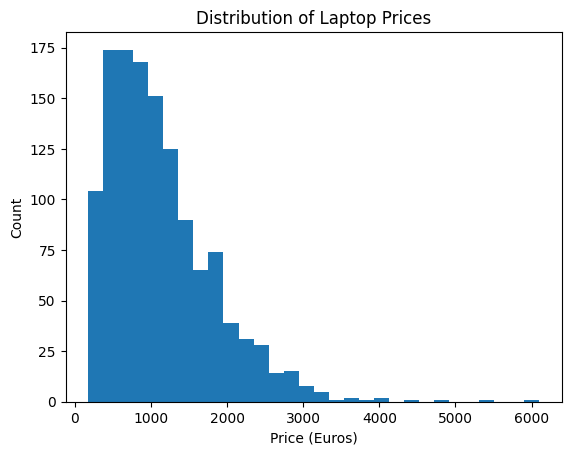

In [14]:
# Exploratory Data Analysis (EDA)
# Price Distribution

plt.figure()
plt.hist(df["Price_euros"], bins=30)
plt.title("Distribution of Laptop Prices")
plt.xlabel("Price (Euros)")
plt.ylabel("Count")
plt.show()

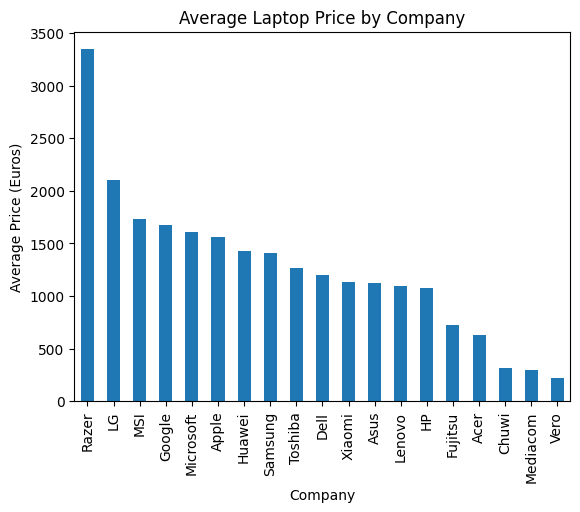

In [15]:
# Average Laptop Price by Company

avreage_price = df.groupby("Company")["Price_euros"].mean().sort_values(ascending = False)
plt.figure()
avreage_price.plot(kind = "bar")
plt.title("Average Laptop Price by Company")
plt.xlabel("Company")
plt.ylabel("Average Price (Euros)")
plt.show()

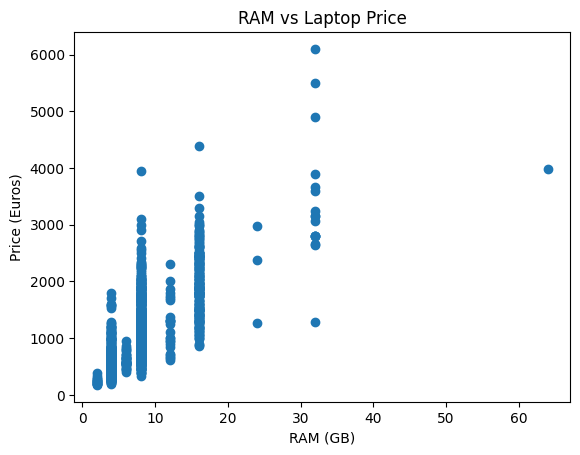

In [16]:
# RAM vs Laptop Price 

plt.figure()
plt.scatter(df["Ram"], df["Price_euros"])
plt.title("RAM vs Laptop Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price (Euros)")
plt.show()

In [17]:
# Convert Categorical → Numerical

df = pd.get_dummies(df, drop_first=True)

In [18]:
# Define Features & Target

X = df.drop("Price_euros", axis=1)
y = df["Price_euros"]

In [19]:
print(type(X))

<class 'pandas.core.frame.DataFrame'>


In [20]:
# Split in Train and Test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# Model Building
# Random Forest Regressor

rf = RandomForestRegressor(n_estimators=200,random_state=45)
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
import pickle

# Save
pickle.dump(rf, open("laptop_model.pkl", "wb"))
pickle.dump(X.columns, open("columns.pkl", "wb"))

# Load
model = pickle.load(open("laptop_model.pkl", "rb"))
columns = pickle.load(open("columns.pkl", "rb"))

In [23]:
# Prediction
rf_y_pred = rf.predict(X_test)

In [24]:
# Model Evaluation

print("R2 Score:", r2_score(y_test, rf_y_pred))
print("MAE:", mean_absolute_error(y_test, rf_y_pred))
print("RMSE:",np.sqrt(mean_squared_error(y_test, rf_y_pred)))

R2 Score: 0.8703528985366277
MAE: 171.8528249309057
RMSE: 253.6709449590893


In [26]:
# Laptop Price Prediction GUI (Tkinter)
from tkinter import *
import tkinter as tk
from tkinter import ttk, messagebox
from PIL import Image, ImageTk


def predict_price():
    try:
        company = company_var.get()
        product = product_entry.get()
        cpu = cpu_var.get()
        ram = int(ram_entry.get())
        os = os_var.get()
        weight = float(weight_entry.get())

        input_data = {
            "Company": company,
            "Product": product,
            "Cpu": cpu,
            "Ram": ram,
            "OpSys": os,
            "Weight": weight
        }

        input_df = pd.DataFrame([input_data])

        # Apply same preprocessing
        input_df = pd.get_dummies(input_df)

        # 🔥 IMPORTANT FIX
        input_df = input_df.reindex(columns=columns, fill_value=0)

        # Ensure it's DataFrame (not array)
        prediction = rf.predict(input_df)[0]

        result_label.config(text=f"Predicted Price:  {round(prediction, 2)}")

    except Exception as e:
        messagebox.showerror("Error", str(e))
        
# GUI Window
root = tk.Tk()
root.title("Laptop Price Predictor")
root.geometry("925x500+300+200")
root.configure(bg = "#fff")
root.resizable(False,False)

def load_image():
    global label
    img = Image.open("C:/Users/Kanti/Downloads/image.png")
    img = img.resize((450, 400))
    
    img_tk = ImageTk.PhotoImage(img)

    label = tk.Label(root, image=img_tk, bg="white")
    label.image = img_tk   # 🔥 important
    label.place(x=50, y=50)
load_image()

tk.Label(root, text="Laptop Price Prediction", bg="white", font=("Microsoft YaHei UI Light", 20, "bold")).place(x = 300, y = 10)

# Company Dropdown
tk.Label(root, text="COMPANY",bg="white", font=("Microsoft YaHei UI Light", 14,"bold")).place(x = 540, y = 100)
company_var = tk.StringVar()
company_dropdown = ttk.Combobox(root, textvariable=company_var, width = 15, font=("Microsoft YaHei UI Light", 14,"bold"))
company_dropdown["values"] = ["Dell", "HP", "Lenovo", "Asus", "Acer", "Apple"]
company_dropdown.place(x = 650, y = 100)

# Product Entry
tk.Label(root, text="PRODUCT",bg="white", font=("Microsoft YaHei UI Light", 14,"bold")).place(x = 540, y = 150)
product_entry = tk.Entry(root, width = 16,border = 2, font=("Microsoft YaHei UI Light", 15,"bold"))
product_entry.place(x = 650, y = 150)

# CPU Dropdown
tk.Label(root, text="CPU MODEL",bg="white", font=("Microsoft YaHei UI Light", 13,"bold")).place(x = 540, y = 200)
cpu_var = tk.StringVar()
cpu_dropdown = ttk.Combobox(root, textvariable=cpu_var, width = 15, font=("Microsoft YaHei UI Light", 14,"bold"))
cpu_dropdown["values"] = ["Intel Core i3", "Intel Core i5", "Intel Core i7", "AMD Ryzen 5"]
cpu_dropdown.place(x = 650, y = 200)

# RAM
tk.Label(root, text="RAM (GB)",bg="white", font=("Microsoft YaHei UI Light", 13,"bold")).place(x = 540, y = 250)
ram_entry = tk.Entry(root, width = 16,border = 2, font=("Microsoft YaHei UI Light", 15,"bold"))
ram_entry.place(x = 650, y = 250)

# OS Dropdown
tk.Label(root, text="O.S",bg="white", font=("Microsoft YaHei UI Light", 13,"bold")).place(x = 540, y = 300)
os_var = tk.StringVar()
os_dropdown = ttk.Combobox(root, textvariable=os_var, width = 15, font=("Microsoft YaHei UI Light", 14,"bold"))
os_dropdown["values"] = ["Windows 10", "Windows 11", "MacOS", "Linux"]
os_dropdown.place(x = 650, y = 300)

# Weight
tk.Label(root, text="WEIGHT(KG)",bg="white", font=("Microsoft YaHei UI Light", 13,"bold")).place(x = 540, y = 350)
weight_entry = tk.Entry(root, width = 16,border = 2, font=("Microsoft YaHei UI Light", 15,"bold"))
weight_entry.place(x = 650, y = 350)

# Predict Button
tk.Button(root, text="PREDICTED PRICE",command=predict_price,bg="blue",fg="white",font=("Microsoft YaHei UI Light", 10,"bold")).place(x = 600, y = 400)

# Result
result_label = tk.Label(root, text="",bg="white", font=("Microsoft YaHei UI Light", 14,"bold"))
result_label.place(x = 550, y = 450)

# Run
root.mainloop()